In [ ]:
# ============================================================
# GSE176178 - BCG Bladder Cancer Genomic Data
# Load from GEO and Save to Google Drive
# ============================================================

# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Install required libraries
!pip install GEOparse -q

# Step 3: Import libraries
import GEOparse
import pandas as pd
import os
import gzip
import shutil
import urllib.request

# Step 4: Define save path
SAVE_DIR = '/content/drive/MyDrive/GSE176178_validation'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

# ============================================================
# Step 5: Load the GEO Series using GEOparse
# ============================================================
print("\nDownloading GSE176178 from GEO...")
gse = GEOparse.get_GEO(geo="GSE176178", destdir=SAVE_DIR, silent=False)

# ============================================================
# Step 6: Extract and Save Metadata
# ============================================================
print("\nExtracting metadata...")

# Series-level metadata
series_meta = {
    'title': gse.metadata.get('title', [''])[0],
    'summary': gse.metadata.get('summary', [''])[0],
    'overall_design': gse.metadata.get('overall_design', [''])[0],
    'submission_date': gse.metadata.get('submission_date', [''])[0],
    'organism': gse.metadata.get('sample_organism', ['Homo sapiens'])[0],
}
series_meta_df = pd.DataFrame([series_meta])
series_meta_df.to_csv(f"{SAVE_DIR}/series_metadata.csv", index=False)
print("Series metadata saved.")

# Sample-level metadata
sample_records = []
for gsm_name, gsm in gse.gsms.items():
    record = {
        'gsm_accession': gsm_name,
        'title': gsm.metadata.get('title', [''])[0],
        'source': gsm.metadata.get('source_name_ch1', [''])[0],
        'organism': gsm.metadata.get('organism_ch1', [''])[0],
        'characteristics': str(gsm.metadata.get('characteristics_ch1', '')),
        'description': gsm.metadata.get('description', [''])[0],
    }
    sample_records.append(record)

sample_meta_df = pd.DataFrame(sample_records)
sample_meta_df.to_csv(f"{SAVE_DIR}/sample_metadata.csv", index=False)
print(f"Sample metadata saved — {len(sample_records)} samples.")

# ============================================================
# Step 7: Download the Processed Count Matrix
# (GSE176178_RNA.featurecounts.txt.gz)
# ============================================================
print("\nDownloading processed RNA featureCounts matrix...")

count_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176178/suppl/GSE176178_RNA.featurecounts.txt.gz"
gz_path   = f"{SAVE_DIR}/GSE176178_RNA.featurecounts.txt.gz"
txt_path  = f"{SAVE_DIR}/GSE176178_RNA.featurecounts.txt"

# Download
urllib.request.urlretrieve(count_url, gz_path)
print("Download complete.")

# Decompress
with gzip.open(gz_path, 'rb') as f_in, open(txt_path, 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)
print("Decompressed successfully.")

# ============================================================
# Step 8: Load Count Matrix into DataFrame
# ============================================================
print("\nLoading count matrix...")
counts_df = pd.read_csv(txt_path, sep='\t', comment='#')
print(f"Count matrix shape: {counts_df.shape}")
print(counts_df.head())

# Save a clean copy as CSV for easy downstream use
counts_csv_path = f"{SAVE_DIR}/GSE176178_featurecounts.csv"
counts_df.to_csv(counts_csv_path, index=False)
print(f"\nCount matrix saved as CSV: {counts_csv_path}")

# ============================================================
# Step 9: Summary
# ============================================================
print("\n" + "="*55)
print("All files saved to:", SAVE_DIR)
print("="*55)
for f in os.listdir(SAVE_DIR):
    fpath = os.path.join(SAVE_DIR, f)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f"  {f:50s}  {size_mb:.2f} MB")

Mounted at /content/drive


26-Apr-2026 21:25:05 DEBUG utils - Directory /content/drive/MyDrive/GSE176178_validation already exists. Skipping.
DEBUG:GEOparse:Directory /content/drive/MyDrive/GSE176178_validation already exists. Skipping.
26-Apr-2026 21:25:05 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176178/soft/GSE176178_family.soft.gz to /content/drive/MyDrive/GSE176178_validation/GSE176178_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176178/soft/GSE176178_family.soft.gz to /content/drive/MyDrive/GSE176178_validation/GSE176178_family.soft.gz


Save directory: /content/drive/MyDrive/GSE176178_validation



100%|██████████| 4.29k/4.29k [00:00<00:00, 18.2kB/s]
26-Apr-2026 21:25:06 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
26-Apr-2026 21:25:06 DEBUG downloader - Moving /tmp/tmpkd7rrmz6 to /content/drive/MyDrive/GSE176178_validation/GSE176178_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpkd7rrmz6 to /content/drive/MyDrive/GSE176178_validation/GSE176178_family.soft.gz
26-Apr-2026 21:25:06 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176178/soft/GSE176178_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176178/soft/GSE176178_family.soft.gz
26-Apr-2026 21:25:06 INFO GEOparse - Parsing /content/drive/MyDrive/GSE176178_validation/GSE176178_family.soft.gz: 
INFO:GEOparse:Parsing /content/drive/MyDrive/GSE176178_validation/GSE176178_family.soft.gz: 
26-Apr-2026 21:25:06 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
26-Apr-2026 21:25:06


Extracting metadata...
Series metadata saved.
Sample metadata saved — 40 samples.

Download complete.
Decompressed successfully.

Loading count matrix...
Count matrix shape: (59412, 46)
        Geneid                    Chr  \
0      DDX11L1      1;1;1;1;1;1;1;1;1   
1       WASH7P  1;1;1;1;1;1;1;1;1;1;1   
2    MIR6859-1                      1   
3  MIR1302-2HG              1;1;1;1;1   
4    MIR1302-2                      1   

                                               Start  \
0  11869;12010;12179;12613;12613;12975;13221;1322...   
1  14404;15005;15796;16607;16858;17233;17606;1791...   
2                                              17369   
3                      29554;30267;30564;30976;30976   
4                                              30366   

                                                 End                 Strand  \
0  12227;12057;12227;12721;12697;13052;13374;1440...      +;+;+;+;+;+;+;+;+   
1  14501;15038;15947;16765;17055;17368;17742;1806...  -;-;-;-;-;-;-;-;-

In [ ]:
# Check what's inside the sample metadata
import pandas as pd

sample_meta_df = pd.read_csv('/content/drive/MyDrive/GSE176178_validation/sample_metadata.csv')

# See all columns
print(sample_meta_df.columns.tolist())
print("\n")

# See full characteristics field for all samples
pd.set_option('display.max_colwidth', None)
print(sample_meta_df[['gsm_accession', 'title', 'source', 'characteristics']].to_string())

['gsm_accession', 'title', 'source', 'organism', 'characteristics', 'description']


   gsm_accession title                        source                                     characteristics
0     GSM5359407    1A  stage 1 bladder cancer tumor     ['bcg response: No', 'age: 69', 'gender: Male']
1     GSM5359408    2A  stage 1 bladder cancer tumor     ['bcg response: No', 'age: 69', 'gender: Male']
2     GSM5359409    3A  stage 1 bladder cancer tumor     ['bcg response: No', 'age: 80', 'gender: Male']
3     GSM5359410    4A  stage 1 bladder cancer tumor  ['bcg response: Yes', 'age: 78', 'gender: Female']
4     GSM5359411    5A  stage 1 bladder cancer tumor     ['bcg response: No', 'age: 72', 'gender: Male']
5     GSM5359412    6A  stage 1 bladder cancer tumor     ['bcg response: No', 'age: 63', 'gender: Male']
6     GSM5359413    7A  stage 1 bladder cancer tumor     ['bcg response: No', 'age: 76', 'gender: Male']
7     GSM5359414    8A  stage 1 bladder cancer tumor     ['bcg response: No

In [ ]:
# Dig into raw GSM metadata fields
for gsm_name, gsm in gse.gsms.items():
    print(f"\n{gsm_name}:")
    for key, val in gsm.metadata.items():
        print(f"  {key}: {val}")
    break  # Remove 'break' to see all 40 samples


GSM5359407:
  title: ['1A']
  geo_accession: ['GSM5359407']
  status: ['Public on Jun 05 2021']
  submission_date: ['Jun 04 2021']
  last_update_date: ['Jun 06 2021']
  type: ['SRA']
  channel_count: ['1']
  source_name_ch1: ['stage 1 bladder cancer tumor']
  organism_ch1: ['Homo sapiens']
  taxid_ch1: ['9606']
  characteristics_ch1: ['bcg response: No', 'age: 69', 'gender: Male']
  molecule_ch1: ['total RNA']
  extract_protocol_ch1: ['RNA libraries were prepared for sequencing using standard Illumina protocols']
  data_processing: ['Sequenced reads were quality checked and reads were aligned to the human genome hg38 reference set using STAR aligner.', 'For gene expression analysis, counts of mapped reads for the genes were calculated by featureCounts in the R package SubRead.', 'These read counts were used as input for DESeq2 to identify significant differentially expressed genes between durable responders and BCG non-durable responder samples.', 'For RNA-seq variant calling, aligned

In [ ]:
import pandas as pd
import ast

# Load metadata
sample_meta_df = pd.read_csv('/content/drive/MyDrive/GSE176178_validation/sample_metadata.csv')

# Parse characteristics column
def parse_characteristics(char_str):
    char_list = ast.literal_eval(char_str)
    result = {}
    for item in char_list:
        key, val = item.split(': ', 1)
        result[key.strip()] = val.strip()
    return result

# Apply parsing
parsed = sample_meta_df['characteristics'].apply(parse_characteristics)
parsed_df = pd.DataFrame(parsed.tolist())

# Combine with accession and title
meta_clean = pd.concat([
    sample_meta_df[['gsm_accession', 'title']],
    parsed_df
], axis=1)

# Rename for clarity
meta_clean.rename(columns={
    'title': 'sample_id',
    'bcg response': 'bcg_response',
    'age': 'age',
    'gender': 'gender'
}, inplace=True)

meta_clean['age'] = meta_clean['age'].astype(int)

print(meta_clean)
print("\nValue counts:")
print(meta_clean['bcg_response'].value_counts())

# Save
meta_clean.to_csv('/content/drive/MyDrive/GSE176178_validation/sample_metadata_clean.csv', index=False)
print("\nSaved: sample_metadata_clean.csv")

   gsm_accession sample_id bcg_response  age  gender
0     GSM5359407        1A           No   69    Male
1     GSM5359408        2A           No   69    Male
2     GSM5359409        3A           No   80    Male
3     GSM5359410        4A          Yes   78  Female
4     GSM5359411        5A           No   72    Male
5     GSM5359412        6A           No   63    Male
6     GSM5359413        7A           No   76    Male
7     GSM5359414        8A           No   70    Male
8     GSM5359415        9A           No   69    Male
9     GSM5359416       12A           No   62    Male
10    GSM5359417       13A           No   75    Male
11    GSM5359418       14A           No   57  Female
12    GSM5359419       15A           No   66    Male
13    GSM5359420       16A           No   65    Male
14    GSM5359421       17A           No   70    Male
15    GSM5359422       18A          Yes   65    Male
16    GSM5359423       19A          Yes   62  Female
17    GSM5359424       20A          Yes   70  

In [ ]:
import pandas as pd

# Load count matrix
counts_df = pd.read_csv('/content/drive/MyDrive/GSE176178_validation/GSE176178_featurecounts.csv')

# Check Geneid column
print("Total genes:", len(counts_df))
print("\nFirst 10 gene names:")
print(counts_df['Geneid'].head(10).tolist())

# Check if any look like Ensembl IDs (ENSG...)
ensembl_check = counts_df['Geneid'].str.startswith('ENSG').sum()
print(f"\nEnsembl IDs present: {ensembl_check}")
print(f"Gene symbols present: {len(counts_df) - ensembl_check}")

# Check annotation columns vs sample columns
annotation_cols = ['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length']
sample_cols = [c for c in counts_df.columns if c not in annotation_cols]

print(f"\nAnnotation columns: {annotation_cols}")
print(f"\nSample columns ({len(sample_cols)}): {sample_cols}")

Total genes: 59412

First 10 gene names:
['DDX11L1', 'WASH7P', 'MIR6859-1', 'MIR1302-2HG', 'MIR1302-2', 'FAM138A', 'OR4G4P', 'OR4G11P', 'OR4F5', 'AL627309.1']

Ensembl IDs present: 0
Gene symbols present: 59412

Annotation columns: ['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length']

Sample columns (40): ['12A', '13A', '14A', '15A', '16A', '17A', '18A', '19A', '1A', '20A', '21A', '22A', '23A', '24A', '25A', '26A', '27A', '28A', '29A', '2A', '30A', '32A', '34A', '35A', '36A', '37A', '38A', '39A', '3A', '42A', '43A', '45A', '46A', '47A', '4A', '5A', '6A', '7A', '8A', '9A']


In [ ]:
import pandas as pd
import ast

# ============================================================
# Load files
# ============================================================
counts_df = pd.read_csv('/content/drive/MyDrive/GSE176178_validation/GSE176178_featurecounts.csv')
meta_clean = pd.read_csv('/content/drive/MyDrive/GSE176178_validation/sample_metadata_clean.csv')

# ============================================================
# Step 1: Clean count matrix — keep only Geneid + sample cols
# ============================================================
annotation_cols = ['Chr', 'Start', 'End', 'Strand', 'Length']
counts_clean = counts_df.drop(columns=annotation_cols)

# Set Geneid as index
counts_clean = counts_clean.set_index('Geneid')

print("Count matrix shape:", counts_clean.shape)
print(counts_clean.head())

# ============================================================
# Step 2: Transpose — rows = samples, columns = genes
# ============================================================
counts_T = counts_clean.T  # Now: 40 samples x 59412 genes
counts_T.index.name = 'sample_id'
counts_T = counts_T.reset_index()

print("\nTransposed shape:", counts_T.shape)

# ============================================================
# Step 3: Merge with metadata (sample_id + bcg_response)
# ============================================================
meta_subset = meta_clean[['sample_id', 'gsm_accession', 'bcg_response', 'age', 'gender']]

final_df = meta_subset.merge(counts_T, on='sample_id', how='inner')

# Reorder: metadata first, then genes
meta_cols = ['sample_id', 'gsm_accession', 'bcg_response', 'age', 'gender']
gene_cols  = [c for c in final_df.columns if c not in meta_cols]

final_df = final_df[meta_cols + gene_cols]

print("\nFinal matrix shape:", final_df.shape)
print(final_df.iloc[:5, :8])  # Preview first 8 columns

# ============================================================
# Step 4: Save full matrix
# ============================================================
out_path = '/content/drive/MyDrive/GSE176178_validation/GSE176178_patient_gene_matrix.csv'
final_df.to_csv(out_path, index=False)
print(f"\nSaved full matrix: {out_path}")



Count matrix shape: (59412, 40)
             12A  13A  14A  15A  16A  17A  18A  19A   1A  20A  ...  43A  45A  \
Geneid                                                         ...             
DDX11L1        0    0    3    4   26    2    2    0    1   13  ...    0    2   
WASH7P       360  125  103  206  208  164  388   24  142  274  ...  106  221   
MIR6859-1      0    0    1    0    1    0    3    0    0    0  ...    0    0   
MIR1302-2HG    0    0    0    0    0    0    0    0    0    0  ...    0    0   
MIR1302-2      0    0    0    0    0    0    0    0    0    0  ...    0    0   

             46A  47A   4A  5A  6A   7A   8A   9A  
Geneid                                             
DDX11L1        2    0    2   3   0    2    6    9  
WASH7P        89   16  157  85  55  168  277  123  
MIR6859-1      0    0    1   0   0    0    1    0  
MIR1302-2HG    0    0    0   0   0    0    0    0  
MIR1302-2      0    0    0   0   0    0    0    0  

[5 rows x 40 columns]

Transposed shape: (

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import roc_auc_score

# ============================================================
# Step 1: Load your gene signature
# ============================================================
sig_file = pd.read_csv('/content/drive/MyDrive/BCG_MOFA_output/hspc_analysis/BCG_signature_core_50.csv')
my_genes = sig_file['gene'].tolist()
print(f"Total signature genes: {len(my_genes)}")
print(f"First 10: {my_genes[:10]}")

# ============================================================
# Step 2: Load the patient-gene matrix
# ============================================================
final_df = pd.read_csv('/content/drive/MyDrive/GSE176178_validation/GSE176178_patient_gene_matrix.csv')
print(f"\nPatient matrix shape: {final_df.shape}")

# ============================================================
# Step 3: Check gene overlap
# ============================================================
meta_cols  = ['sample_id', 'gsm_accession', 'bcg_response', 'age', 'gender']
gene_cols  = [c for c in final_df.columns if c not in meta_cols]

available_genes = [g for g in my_genes if g in gene_cols]
missing_genes   = [g for g in my_genes if g not in gene_cols]

print(f"\nSignature genes found in dataset : {len(available_genes)}")
print(f"Signature genes NOT found        : {len(missing_genes)}")
print(f"Missing genes: {missing_genes}")

# ============================================================
# Step 4: Create signature matrix
# ============================================================
sig_matrix = final_df[meta_cols + available_genes].copy()

# Split by response group
responders     = sig_matrix[sig_matrix['bcg_response'] == 'Yes']
non_responders = sig_matrix[sig_matrix['bcg_response'] == 'No']

print(f"\nResponders    : {len(responders)}")
print(f"Non-Responders: {len(non_responders)}")

# ============================================================
# Step 5: Per-gene stats — p-value + AUC
# ============================================================
# Binary label: Yes=1, No=0
y_true = (sig_matrix['bcg_response'] == 'Yes').astype(int).values

results = []

for gene in available_genes:
    r_vals  = responders[gene].values
    nr_vals = non_responders[gene].values
    all_vals = sig_matrix[gene].values

    # Mann-Whitney U test
    try:
        stat, pval = stats.mannwhitneyu(r_vals, nr_vals, alternative='two-sided')
    except Exception:
        pval = np.nan

    # AUC
    try:
        auc = roc_auc_score(y_true, all_vals)
        # Flip if AUC < 0.5 (gene suppressed in responders)
        if auc < 0.5:
            auc_flipped = 1 - auc
            direction   = 'down_in_responders'
        else:
            auc_flipped = auc
            direction   = 'up_in_responders'
    except Exception:
        auc_flipped = np.nan
        direction   = 'NA'

    results.append({
        'gene'           : gene,
        'mean_responder' : round(r_vals.mean(), 3),
        'mean_nonresp'   : round(nr_vals.mean(), 3),
        'log2FC'         : round(np.log2((r_vals.mean() + 1) / (nr_vals.mean() + 1)), 3),
        'p_value'        : round(pval, 5),
        'AUC'            : round(auc_flipped, 3),
        'direction'      : direction,
    })

results_df = pd.DataFrame(results)

# Add FDR correction (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
reject, pvals_corr, _, _ = multipletests(results_df['p_value'].fillna(1), method='fdr_bh')
results_df['p_adj_BH'] = pvals_corr.round(5)
results_df['significant'] = reject

# Sort by AUC descending
results_df = results_df.sort_values('AUC', ascending=False).reset_index(drop=True)

# ============================================================
# Step 6: Display results
# ============================================================
print("\n===== TOP GENES BY AUC =====")
print(results_df.head(20).to_string(index=False))

print("\n===== SIGNIFICANT GENES (p_adj < 0.05) =====")
sig_genes = results_df[results_df['p_adj_BH'] < 0.05]
print(sig_genes.to_string(index=False))

print(f"\nTotal significant genes: {len(sig_genes)}")

# ============================================================
# Step 7: Save results
# ============================================================
out_path = '/content/drive/MyDrive/GSE176178_validation/BCG_signature_validation_results.csv'
results_df.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

# ============================================================
# Step 8: Overall signature score per patient (mean expression)
# ============================================================
sig_matrix = sig_matrix.copy()
sig_matrix['signature_score'] = sig_matrix[available_genes].mean(axis=1)

# AUC of signature score
score_auc = roc_auc_score(y_true, sig_matrix['signature_score'].values)
print(f"\n===== OVERALL SIGNATURE SCORE AUC =====")
print(f"AUC of mean signature score: {score_auc:.4f}")

# Mean score per group
print("\nMean signature score by group:")
print(sig_matrix.groupby('bcg_response')['signature_score'].mean().round(3))

# Mann-Whitney on signature score
r_scores  = sig_matrix[sig_matrix['bcg_response'] == 'Yes']['signature_score'].values
nr_scores = sig_matrix[sig_matrix['bcg_response'] == 'No']['signature_score'].values
_, score_pval = stats.mannwhitneyu(r_scores, nr_scores, alternative='two-sided')
print(f"Signature score p-value     : {score_pval:.5f}")

# Save score matrix
score_path = '/content/drive/MyDrive/GSE176178_validation/GSE176178_signature_scores.csv'
sig_matrix[meta_cols + ['signature_score']].to_csv(score_path, index=False)
print(f"Saved: {score_path}")

Total signature genes: 50
First 10: ['NKAIN2', 'NRIP1', 'SSBP2', 'SPINK2', 'MEIS1', 'ATP8B4', 'ANKRD28', 'RBPMS', 'PLCB1', 'CHRM3']

Patient matrix shape: (40, 59417)

Signature genes found in dataset : 50
Signature genes NOT found        : 0
Missing genes: []

Responders    : 17
Non-Responders: 23

===== TOP GENES BY AUC =====
   gene  mean_responder  mean_nonresp  log2FC  p_value   AUC          direction  p_adj_BH  significant
   ETV6        1498.647      2124.652  -0.503  0.00572 0.760 down_in_responders   0.18325        False
    VIM        4954.412      9605.826  -0.955  0.00733 0.752 down_in_responders   0.18325        False
  MSRB3         159.118       135.609   0.229  0.01792 0.723 down_in_responders   0.26680        False
  SSBP2         361.647       543.870  -0.587  0.02398 0.712 down_in_responders   0.26680        False
 ATP2B1        3686.529      5013.217  -0.443  0.02668 0.708 down_in_responders   0.26680        False
  BAALC          38.588       104.130  -1.409  0.044

=== XIST expression by Gender ===
gender
Female    140272.1
Male        4262.7
Name: XIST, dtype: float64

=== Gender distribution by BCG response ===
gender        Female  Male
bcg_response              
No                 2    21
Yes                7    10

Genes UP in responders   : 15 → ['XIST', 'AVP', 'BAALC-AS1', 'HOXA9', 'IMMP2L', 'PRSS57', 'MED12L', 'COL24A1', 'SPINK2', 'PDZD2', 'PRKG2', 'LRMDA', 'ANXA1', 'CRHBP', 'SLC8A3']
Genes DOWN in responders : 85

=== Signature Score WITHOUT XIST ===
AUC    : 0.3120
p-value: 0.04580

=== Gender-stratified signature AUC ===
  Male: AUC=0.343, p=0.1696, n=31
  Female: AUC=0.429, p=0.8889, n=9


/tmp/ipykernel_3509/1208127854.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scores_df_merged, x='bcg_response', y='signature_score',
/tmp/ipykernel_3509/1208127854.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df_plot, x='bcg_response', y='score_no_xist',


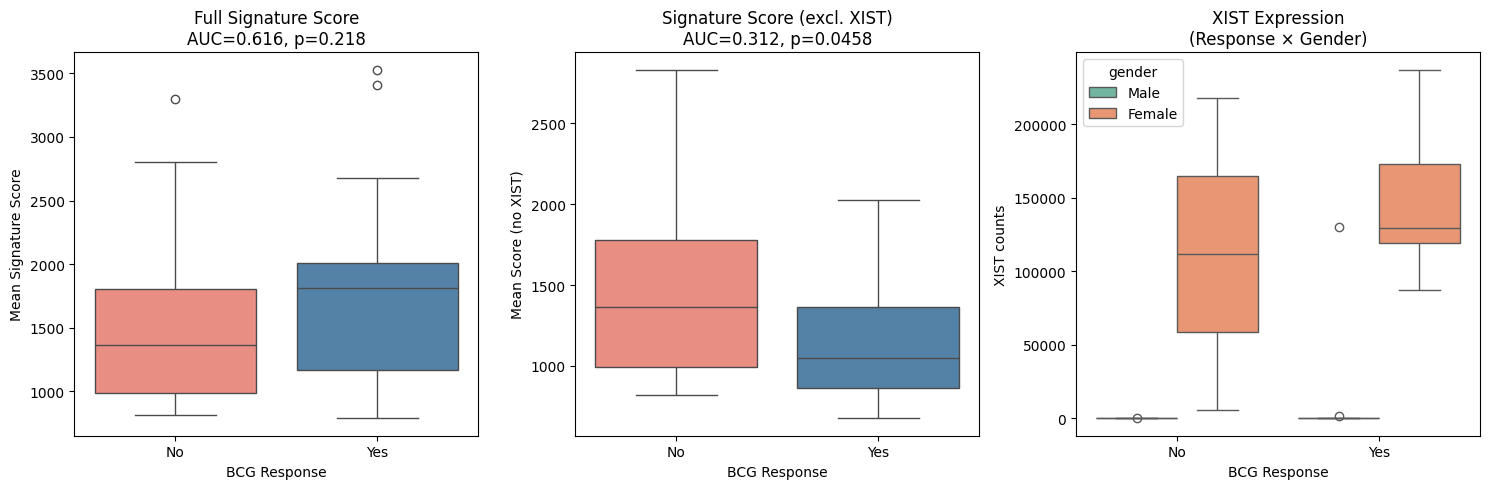


Plot saved!

=== Full results ranked by AUC ===
      gene  mean_responder  mean_nonresp  log2FC  p_value   AUC          direction  p_adj_BH
      XIST       68844.294      9749.522   2.820  0.00034 0.836   up_in_responders   0.03150
    ANTXR2         375.353       769.522  -1.034  0.00063 0.821 down_in_responders   0.03150
      ETV6        1498.647      2124.652  -0.503  0.00572 0.760 down_in_responders   0.15583
       VIM        4954.412      9605.826  -0.955  0.00733 0.752 down_in_responders   0.15583
    CALCRL         229.059       391.609  -0.771  0.00796 0.749 down_in_responders   0.15583
    PLXDC2         649.824      1234.174  -0.924  0.00935 0.744 down_in_responders   0.15583
     GNAI1         268.824       527.609  -0.970  0.01094 0.739 down_in_responders   0.15629
      GPHN        1451.176      2030.957  -0.485  0.01606 0.726 down_in_responders   0.17920
      EMCN         133.941       228.478  -0.766  0.01730 0.724 down_in_responders   0.17920
     MSRB3         15

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Load files
# ============================================================
final_df  = pd.read_csv('/content/drive/MyDrive/GSE176178_validation/GSE176178_patient_gene_matrix.csv')
results   = pd.read_csv('/content/drive/MyDrive/GSE176178_validation/BCG_signature_validation_results.csv')
scores_df = pd.read_csv('/content/drive/MyDrive/GSE176178_validation/GSE176178_signature_scores.csv')

meta_cols = ['sample_id', 'gsm_accession', 'bcg_response', 'age', 'gender']

# ============================================================
# 1. Check XIST vs Gender
# ============================================================
print("=== XIST expression by Gender ===")
print(final_df.groupby('gender')['XIST'].mean().round(1))

print("\n=== Gender distribution by BCG response ===")
print(pd.crosstab(final_df['bcg_response'], final_df['gender']))

# ============================================================
# 2. Rerun AUC excluding XIST — use only "up" direction genes
# ============================================================
sig_file = pd.read_csv('/content/drive/MyDrive/BCG_MOFA_output/hspc_analysis/BCG_signature_standard_100.csv')
my_genes = sig_file['gene'].tolist()

# Merge results with direction info
up_genes = results[results['direction'] == 'up_in_responders']['gene'].tolist()
down_genes = results[results['direction'] == 'down_in_responders']['gene'].tolist()

print(f"\nGenes UP in responders   : {len(up_genes)} → {up_genes}")
print(f"Genes DOWN in responders : {len(down_genes)}")

# ============================================================
# 3. Signature score WITHOUT XIST
# ============================================================
from sklearn.metrics import roc_auc_score

y_true = (final_df['bcg_response'] == 'Yes').astype(int).values

genes_no_xist = [g for g in my_genes if g != 'XIST']
final_df['score_no_xist'] = final_df[genes_no_xist].mean(axis=1)

auc_no_xist = roc_auc_score(y_true, final_df['score_no_xist'])
_, pval_no_xist = stats.mannwhitneyu(
    final_df[final_df['bcg_response']=='Yes']['score_no_xist'],
    final_df[final_df['bcg_response']=='No']['score_no_xist'],
    alternative='two-sided'
)
print(f"\n=== Signature Score WITHOUT XIST ===")
print(f"AUC    : {auc_no_xist:.4f}")
print(f"p-value: {pval_no_xist:.5f}")

# ============================================================
# 4. Gender-stratified analysis
# ============================================================
print("\n=== Gender-stratified signature AUC ===")
for gender in ['Male', 'Female']:
    sub = final_df[final_df['gender'] == gender].copy()
    if sub['bcg_response'].nunique() < 2:
        print(f"{gender}: only one response group — skipping")
        continue
    y_sub = (sub['bcg_response'] == 'Yes').astype(int).values
    score_sub = sub[genes_no_xist].mean(axis=1).values
    try:
        auc_sub = roc_auc_score(y_sub, score_sub)
        _, p_sub = stats.mannwhitneyu(
            sub[sub['bcg_response']=='Yes'][genes_no_xist].mean(axis=1),
            sub[sub['bcg_response']=='No'][genes_no_xist].mean(axis=1),
            alternative='two-sided'
        )
        print(f"  {gender}: AUC={auc_sub:.3f}, p={p_sub:.4f}, n={len(sub)}")
    except:
        print(f"  {gender}: Could not compute AUC")

# ============================================================
# 5. Plot: Signature score boxplot by response
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# A) Full signature score
scores_df_merged = scores_df.merge(final_df[['sample_id','gender']], on='sample_id')
sns.boxplot(data=scores_df_merged, x='bcg_response', y='signature_score',
            palette={'Yes':'steelblue','No':'salmon'}, ax=axes[0])
axes[0].set_title(f'Full Signature Score\nAUC=0.616, p=0.218')
axes[0].set_xlabel('BCG Response')
axes[0].set_ylabel('Mean Signature Score')

# B) Score without XIST
final_df_plot = final_df[['sample_id','bcg_response','gender','score_no_xist']].copy()
sns.boxplot(data=final_df_plot, x='bcg_response', y='score_no_xist',
            palette={'Yes':'steelblue','No':'salmon'}, ax=axes[1])
axes[1].set_title(f'Signature Score (excl. XIST)\nAUC={auc_no_xist:.3f}, p={pval_no_xist:.4f}')
axes[1].set_xlabel('BCG Response')
axes[1].set_ylabel('Mean Score (no XIST)')

# C) XIST expression by response + gender
final_df['label'] = final_df['bcg_response'] + '_' + final_df['gender']
sns.boxplot(data=final_df, x='bcg_response', y='XIST',
            hue='gender', palette='Set2', ax=axes[2])
axes[2].set_title('XIST Expression\n(Response × Gender)')
axes[2].set_xlabel('BCG Response')
axes[2].set_ylabel('XIST counts')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GSE176178_validation/BCG_signature_validation_plots.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved!")

# ============================================================
# 6. Top genes summary table
# ============================================================
print("\n=== Full results ranked by AUC ===")
print(results[['gene','mean_responder','mean_nonresp',
               'log2FC','p_value','AUC','direction','p_adj_BH']].to_string(index=False))